# Modelado en Sklearn

## Librerias

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix, roc_curve, auc,roc_auc_score,average_precision_score,precision_recall_curve,
    RocCurveDisplay
)
import time
import joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Carga de datos

se realiza la carga de los datos tomando una muestra representativa de 1 millon de datos y una subsample de las variables mas relevantes

In [3]:
cols = ["click","dia_semana","hora_del_dia","franja_horaria","device_type","device_conn_type","device_model","site_id","site_domain","app_domain","app_category","app_id","banner_pos","C1","C14","C18"]

In [4]:
chunks = []
for batch in pq.ParquetFile("../docs/datos_procesados.parquet").iter_batches(
        batch_size=100_000, columns=cols):
    chunks.append(batch.to_pandas())

df = pd.concat(chunks, ignore_index=True)

In [5]:
df["hour_sin"] = np.sin(2 * np.pi * df["hora_del_dia"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hora_del_dia"] / 24)

## Split de datos

realizamos el split entre train y test estratificado 

In [6]:
df_sample = df.sample(n=1_000_000, random_state=0)

In [7]:
high_card_cols = [
    "site_domain",
    "app_domain",
    "device_model",
    "C14",
    "C18"
]

low_card_cols = [
    "app_category",
    "banner_pos",
    "device_type",
    "device_conn_type",
    "dia_semana",
    "franja_horaria",
]

num_cols = [
    "hour_sin",   
    "hour_cos",
]

In [8]:
all_features = high_card_cols + low_card_cols + num_cols

In [9]:
X = df_sample[all_features]
y = df_sample["click"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          
    random_state=0
)


In [11]:
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Balance train - click=1: {y_train.mean():.3f}")
print(f"Balance test  - click=1: {y_test.mean():.3f}")

Train: (800000, 13) | Test: (200000, 13)
Balance train - click=1: 0.170
Balance test  - click=1: 0.170


## Creacion de pipelines 

Se crean pipelines para el preprocesamiento de datos

In [12]:
high_card_pipeline = ImbPipeline(steps=[
    ("target_encoder", TargetEncoder(smoothing=10))
])

In [13]:
low_card_pipeline = ImbPipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

In [14]:
num_pipeline = ImbPipeline(steps=[
    ("scaler", StandardScaler())
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("high_card", high_card_pipeline, high_card_cols),
        ("low_card",  low_card_pipeline,  low_card_cols),
        ("num",       num_pipeline,       num_cols),
    ],
    remainder='drop'
)

In [16]:
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=2048,
    max_iter=100,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=0
))
])

## Modelado benchmark

### Modelo inicial

In [17]:
start=time.time()
benchmark=pipeline.fit(X_train, y_train)
end=time.time()
print(f"Tiempo estimado: {(end - start) / 60:.2f} minutos")

Tiempo estimado: 5.51 minutos


In [18]:
y_pred = benchmark.predict(X_test)
y_proba = benchmark.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.830435
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    166087
           1       0.00      0.00      0.00     33913

    accuracy                           0.83    200000
   macro avg       0.42      0.50      0.45    200000
weighted avg       0.69      0.83      0.75    200000



podemos observar que hay bastante overfitting en la clase 0, con un porcentaje bastante alto de accuracy a pesar de que en la clase 1 esta todo en 0 

In [19]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.5044170979599552


a pesar de que la clase 1 es 0, ROC AUC es igual a 0.5 por lo que no esta discriminando las clases de manera eficiente 

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [21]:
clases      = benchmark.classes_
n_clases    = len(clases)

In [22]:
cm = confusion_matrix(y_test, y_pred)

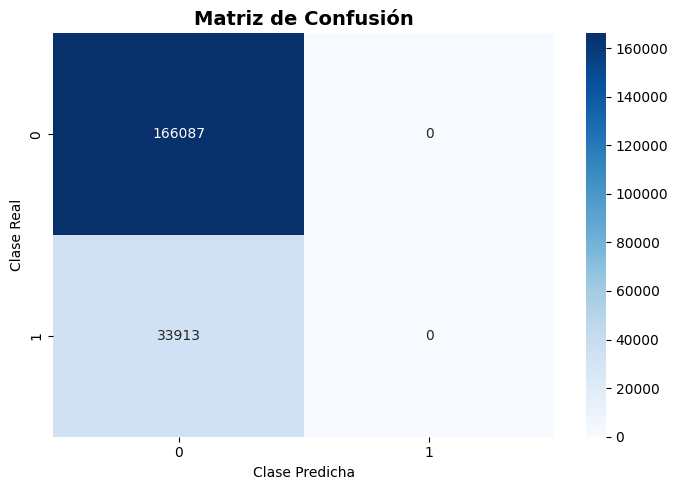

In [23]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de Confusión", fontsize=14, fontweight="bold")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

Podemos observar que nunca predice la clase 1, la ignora completamente

en general esto evidencia el desbalanceo que tiene el dataset entre las clases 0 y 1, por lo que debemos realizar una clase de balanceo, sin embargo balanceos sinteticos tipo SMOTE no son aptos para este dataset de mayoria categorica y ademas class_weight balanced no existe en el modelo. Por este motivo, se procedió a ajustar el umbral de decisión maximizando f1 para de esta manera, realizar un balanceo en las 4 metricas principales 

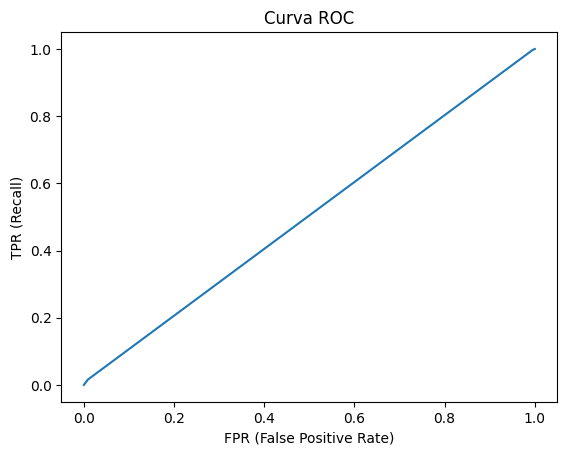

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC")
plt.show()

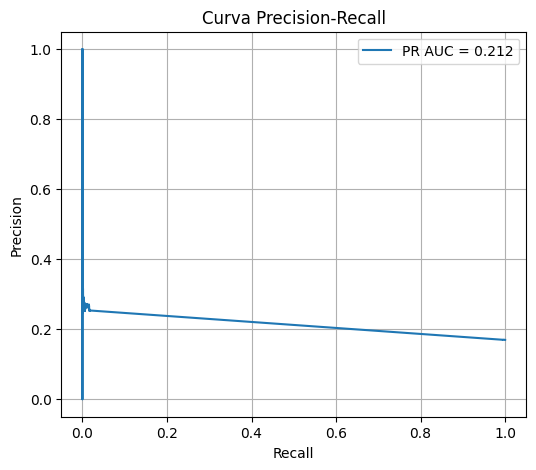

In [25]:
# Calcular precision y recall para distintos thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calcular PR-AUC
pr_auc = auc(recall, precision)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid()
plt.show()

### Modelo balanceado por threshold

Encontramos un threshold que maximize f1_score 

In [26]:
f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1)]

In [27]:
y_pred = (y_proba >= best_threshold).astype(int)

In [28]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)

In [29]:
print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall",recall)
print("F1_score:",f1)

Accuracy:  0.17393
Precision:  0.16989395455482534
Recall 0.9963140978385869
F1_score: 0.2902873834786718


In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.01      0.01    166087
           1       0.17      1.00      0.29     33913

    accuracy                           0.17    200000
   macro avg       0.53      0.50      0.15    200000
weighted avg       0.77      0.17      0.06    200000



podemos observar que incluso realizando el cambio del ajuste del umbral, el recall mantiene un overffiting notable, a pesar de que puede ahora si predecir la clase 1

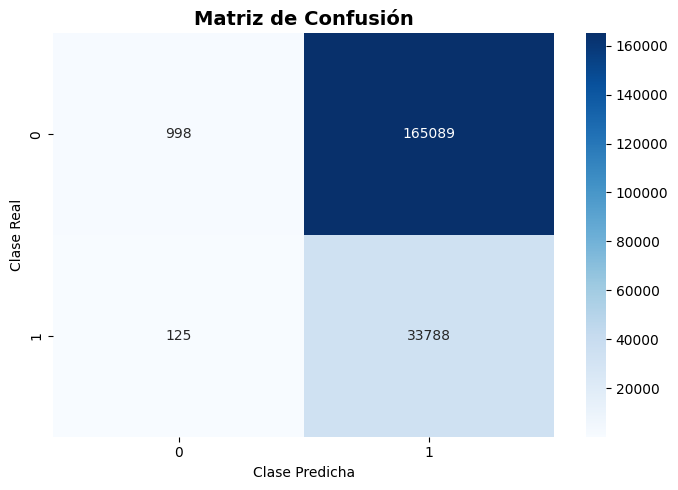

In [31]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de Confusión", fontsize=14, fontweight="bold")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

Podemos observar que al cambiar el threshold de 0.5 en el problema, el modelo captura mucho mejor la clase 1, pero al coste de no predecir bien la clase 0. La busqueda de hiperparametros puede facilitar este problema 

## Gridsearch

Se realiza un gridsearch, modificando los paramteros de hidden layers, alpha y max iter para determinar cual es la combinacion que genera mejores resultados para el modelo

### Entrenamiento de Gridsearch

In [32]:
param_grid = {
    "classifier__hidden_layer_sizes": [
        (128, 64),
        (256, 128),
        (512, 256, 128),      
    ],
    "classifier__alpha": [1e-4, 1e-2],  
    "classifier__max_iter": [50, 100]  
}


In [33]:
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=2048,
    max_iter=100,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=0
))
])

In [34]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",        
    cv=3              
)

In [35]:
start_train = time.time()
grid.fit(X_train, y_train)
end_train = time.time()
train_time = end_train - start_train
print(f"Tiempo total de entrenamiento (GridSearch): {train_time/ 60:.2f} minutos")

Tiempo total de entrenamiento (GridSearch): 120.12 minutos


In [36]:
print("Mejores parámetros:")
print(grid.best_params_)

print("Mejor ROC-AUC (CV):")
print(grid.best_score_)

Mejores parámetros:
{'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__max_iter': 50}
Mejor ROC-AUC (CV):
0.1419046664738584


### Evaluacion de mejor modelo

se realiza la evaluacion del modelo con todas las metricas disponibles 

In [37]:
best_model = grid.best_estimator_
start_evaluate = time.time()
# Probabilidades
y_proba_grid = best_model.predict_proba(X_test)[:, 1]

# Predicción con threshold estándar
y_pred_05 = (y_proba_grid >= 0.5).astype(int)

end_evaluate = time.time()
print(f"Tiempo estimado: {(end_evaluate - start_evaluate) / 60:.2f} minutos")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_grid))
print("Accuracy:", accuracy_score(y_test, y_pred_05))
print("Precision:", precision_score(y_test, y_pred_05))
print("Recall:", recall_score(y_test, y_pred_05))
print("F1:", f1_score(y_test, y_pred_05))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test,y_pred_05))

Tiempo estimado: 0.01 minutos
ROC-AUC: 0.6504230351146721
Accuracy: 0.83049
Precision: 0.6486486486486487
Recall: 0.0007076932149913013
F1: 0.001413843888070692

Matriz de confusión:
[[166074     13]
 [ 33889     24]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    166087
           1       0.65      0.00      0.00     33913

    accuracy                           0.83    200000
   macro avg       0.74      0.50      0.45    200000
weighted avg       0.80      0.83      0.75    200000



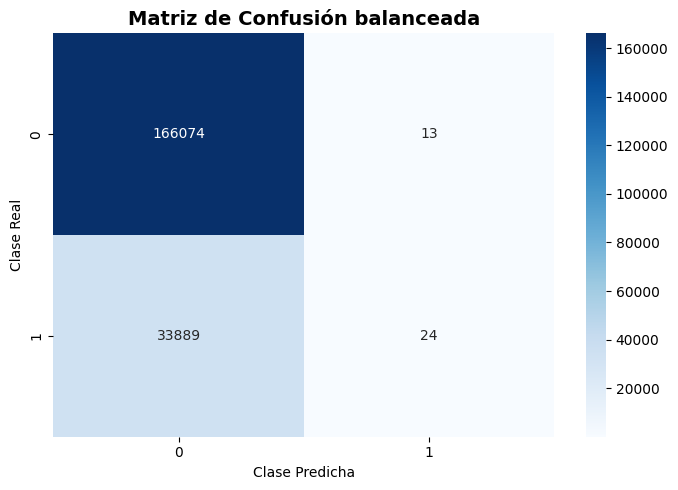

In [38]:
cm_grid = confusion_matrix(y_test, y_pred_05)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_grid,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de Confusión balanceada", fontsize=14, fontweight="bold")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

podemos observar que no se detecta la clase  en las metricas usuales a pesar de tener mejores hiperparametros, por lo que se balanceara con el uso de el ajuste del umbral de decision

In [39]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_proba_grid
)

f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_threshold = thresholds[f1.argmax()]

In [40]:
y_pred_grid = (y_proba_grid >= best_threshold).astype(int)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Precision:", precision_score(y_test, y_pred_grid))
print("Recall:", recall_score(y_test, y_pred_grid))
print("F1:", f1_score(y_test, y_pred_grid))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_grid))
print(classification_report(y_test,y_pred_grid))

Accuracy: 0.569225
Precision: 0.236497528497932
Recall: 0.6912983221773361
F1: 0.3524274106867704

Matriz de confusión:
[[90401 75686]
 [10469 23444]]
              precision    recall  f1-score   support

           0       0.90      0.54      0.68    166087
           1       0.24      0.69      0.35     33913

    accuracy                           0.57    200000
   macro avg       0.57      0.62      0.51    200000
weighted avg       0.78      0.57      0.62    200000



Podemos observar que con el cambio del umbral de decision el modelo es mas eficiente a identificar ambas clases

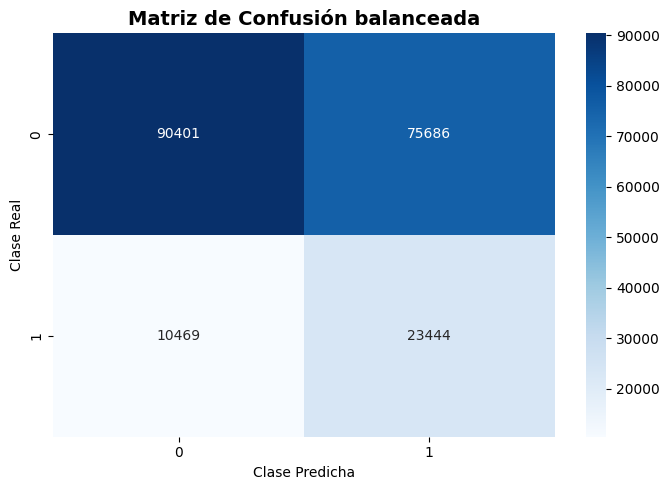

In [42]:
cm_balanceado = confusion_matrix(y_test, y_pred_grid)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_balanceado,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de Confusión balanceada", fontsize=14, fontweight="bold")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

podemos observar que el modelo puede predecir de mejor manera la clase 1 y con la clase 0, a pesar de eso hubo un aumento de los falsos positivos. 

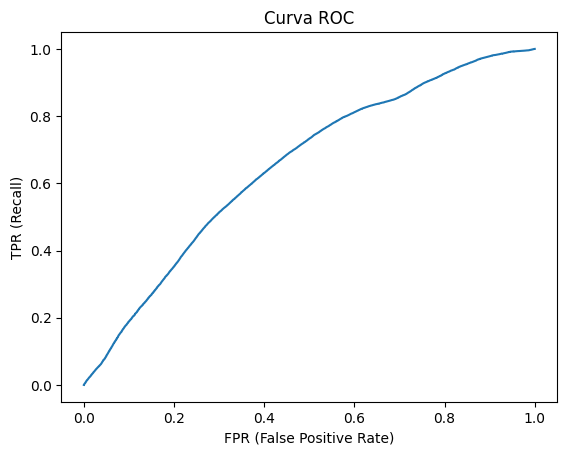

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_grid)
plt.plot(fpr, tpr)
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC")
plt.show()

Podemos observar que la curva ROC ya no es una linea recta, y tiene un valor mayor a 0.6, por lo que discrimina mejor las clases en este caso

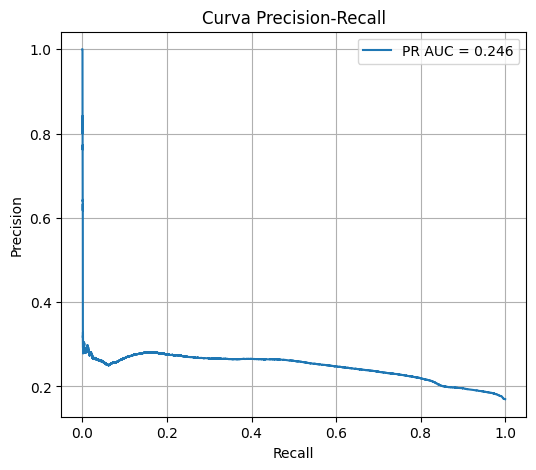

In [44]:
# Calcular precision y recall para distintos thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_grid)

# Calcular PR-AUC
pr_auc = auc(recall, precision)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid()
plt.show()

El ajuste del threshold permitió transformar un modelo inicialmente conservador e incapaz de detectar la clase minoritaria (recall ≈ 0) en un clasificador funcional, capaz de identificar aproximadamente el 70% de los casos positivos. Aunque esto incrementó los falsos positivos, el F1-score mejoró sustancialmente, lo cual es consistente con el comportamiento observado en la curva Precision–Recall y resulta más apropiado para un escenario altamente desbalanceado.